# Week Problem Set: Data Wrangling

## Context
You are a Data Scientist at a regional health center. Patient data is divided across three systems:
- Administrative
- Lab Results
- Lifestyle Surveys

For this assignment, you will work with these datasets **independently** and focus only on **data wrangling tasks**.

---

## Datasets
1. patient_demographics.csv  
   - Patient ID, Age, Sex, Geography
     

2. clinical_data.csv  
   - Patient ID, Cholesterol, Blood Pressure ("120/80"), BMI
  

3. lifestyle_factors.csv  
   - Patient ID, Smoking, Diet, Heart Attack Risk (Target)

---

## Objectives
- Inspecting structure and quality
- Handling missing values
- Fixing data formats
- Identifying and treating anomalies

---

## Important Note
This is a guided notebook. You are expected to:
- Think critically
- Make decisions (and justify them)
- Explore different approaches

---

In [1]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Download the following CSV files from Google Classroom to your computer:

- patient_demographics.csv
- clinical_data.csv
- lifestyle_factors.csv

Run the code below and upload the files.

In [ ]:
from google.colab import files
uploaded = files.upload()

In [4]:
# Load datasets
demographics = pd.read_csv("patient_demographics.csv")
clinical = pd.read_csv("clinical_data.csv")
lifestyle = pd.read_csv("lifestyle_factors.csv")

# Basic Inspection

## Tasks:
- View first few rows
- Check datatypes
- Look at summary statistics

## Questions:
- Are there obvious data issues?
- Are datatypes appropriate?

## Hint:
- Use `.head()`, `.info()`, `.describe()` for all three dataframes to get a full picture of the data quality.
- Pandas documentation for reference: https://pandas.pydata.org/docs/user_guide/10min.html

In [5]:
# Inspecting Demographics
print("---- Patient Demographics ----")
display(demographics.head())
display(demographics.info())
display(demographics.describe(include='all'))

---- Patient Demographics ----


,Patient ID,Age,Sex,Income,Country,Continent,Hemisphere
0,BMW7812,67,Male,261404,Argentina,South America,Southern Hemisphere
1,CZE1114,21,Male,285768,Canada,North America,Northern Hemisphere
2,BNI9906,21,Female,235282,France,Europe,Northern Hemisphere
3,JLN3497,84,Male,125640,Canada,North America,Northern Hemisphere
4,GFO8847,66,Male,160555,Thailand,Asia,Northern Hemisphere


<class 'pandas.DataFrame'>
RangeIndex: 8763 entries, 0 to 8762
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   Patient ID  8763 non-null   str  
 1   Age         8763 non-null   int64
 2   Sex         8763 non-null   str  
 3   Income      8763 non-null   int64
 4   Country     8763 non-null   str  
 5   Continent   8763 non-null   str  
 6   Hemisphere  8763 non-null   str  
dtypes: int64(2), str(5)
memory usage: 479.4 KB


None

,Patient ID,Age,Sex,Income,Country,Continent,Hemisphere
count,8763,8763.000000,8763,8763.000000,8763,8763,8763
unique,8763,NaN,2,NaN,20,6,2
top,BMW7812,NaN,Male,NaN,Germany,Asia,Northern Hemisphere
freq,1,NaN,6111,NaN,477,2543,5660
mean,NaN,53.707977,NaN,158263.181901,NaN,NaN,NaN
std,NaN,21.249509,NaN,80575.190806,NaN,NaN,NaN
min,NaN,18.000000,NaN,20062.000000,NaN,NaN,NaN
25%,NaN,35.000000,NaN,88310.000000,NaN,NaN,NaN
50%,NaN,54.000000,NaN,157866.000000,NaN,NaN,NaN
75%,NaN,72.000000,NaN,227749.000000,NaN,NaN,NaN


In [6]:
# Inspecting Clinical Data
print("\n---- Clinical Data ----")
display(clinical.head())
display(clinical.info())
display(clinical.describe(include='all'))


---- Clinical Data ----


,Patient ID,Cholesterol,Blood Pressure,Heart Rate,Diabetes,Family History,Triglycerides,BMI
0,BMW7812,208,158/88,72,0,0,286,31.251233
1,CZE1114,389,165/93,98,1,1,235,27.194973
2,BNI9906,324,174/99,72,1,0,587,28.176571
3,JLN3497,383,163/100,73,1,1,378,36.464704
4,GFO8847,318,91/88,93,1,1,231,21.809144


<class 'pandas.DataFrame'>
RangeIndex: 8763 entries, 0 to 8762
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Patient ID      8763 non-null   str    
 1   Cholesterol     8763 non-null   int64  
 2   Blood Pressure  8763 non-null   str    
 3   Heart Rate      8763 non-null   int64  
 4   Diabetes        8763 non-null   int64  
 5   Family History  8763 non-null   int64  
 6   Triglycerides   8763 non-null   int64  
 7   BMI             8763 non-null   float64
dtypes: float64(1), int64(5), str(2)
memory usage: 547.8 KB


None

,Patient ID,Cholesterol,Blood Pressure,Heart Rate,Diabetes,Family History,Triglycerides,BMI
count,8763,8763.000000,8763,8763.000000,8763.000000,8763.000000,8763.000000,8763.000000
unique,8763,NaN,3915,NaN,NaN,NaN,NaN,NaN
top,BMW7812,NaN,146/94,NaN,NaN,NaN,NaN,NaN
freq,1,NaN,8,NaN,NaN,NaN,NaN,NaN
mean,NaN,259.877211,NaN,75.021682,0.652288,0.492982,417.677051,28.891446
std,NaN,80.863276,NaN,20.550948,0.476271,0.499979,223.748137,6.319181
min,NaN,120.000000,NaN,40.000000,0.000000,0.000000,30.000000,18.002337
25%,NaN,192.000000,NaN,57.000000,0.000000,0.000000,225.500000,23.422985
50%,NaN,259.000000,NaN,75.000000,1.000000,0.000000,417.000000,28.768999
75%,NaN,330.000000,NaN,93.000000,1.000000,1.000000,612.000000,34.324594


In [7]:
# Inspecting Lifestyle Factors
print("\n---- Lifestyle Factors ----")
display(lifestyle.head())
display(lifestyle.info())
display(lifestyle.describe(include='all'))


---- Lifestyle Factors ----


,Patient ID,Smoking,Obesity,Alcohol Consumption,Exercise Hours Per Week,Diet,Stress Level,Heart Attack Risk
0,BMW7812,1,0,0,4.168189,Average,9,0
1,CZE1114,1,1,1,1.813242,Unhealthy,1,0
2,BNI9906,0,0,0,2.078353,Healthy,9,0
3,JLN3497,1,0,1,9.828130,Average,9,0
4,GFO8847,1,1,0,5.804299,Unhealthy,6,0


<class 'pandas.DataFrame'>
RangeIndex: 8763 entries, 0 to 8762
Data columns (total 8 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Patient ID               8763 non-null   str    
 1   Smoking                  8763 non-null   int64  
 2   Obesity                  8763 non-null   int64  
 3   Alcohol Consumption      8763 non-null   int64  
 4   Exercise Hours Per Week  8763 non-null   float64
 5   Diet                     8763 non-null   str    
 6   Stress Level             8763 non-null   int64  
 7   Heart Attack Risk        8763 non-null   int64  
dtypes: float64(1), int64(5), str(2)
memory usage: 547.8 KB


None

,Patient ID,Smoking,Obesity,Alcohol Consumption,Exercise Hours Per Week,Diet,Stress Level,Heart Attack Risk
count,8763,8763.000000,8763.000000,8763.000000,8763.000000,8763,8763.000000,8763.000000
unique,8763,NaN,NaN,NaN,NaN,3,NaN,NaN
top,BMW7812,NaN,NaN,NaN,NaN,Healthy,NaN,NaN
freq,1,NaN,NaN,NaN,NaN,2960,NaN,NaN
mean,NaN,0.896839,0.501426,0.598083,10.014284,NaN,5.469702,0.358211
std,NaN,0.304186,0.500026,0.490313,5.783745,NaN,2.859622,0.479502
min,NaN,0.000000,0.000000,0.000000,0.002442,NaN,1.000000,0.000000
25%,NaN,1.000000,0.000000,0.000000,4.981579,NaN,3.000000,0.000000
50%,NaN,1.000000,1.000000,1.000000,10.069559,NaN,5.000000,0.000000
75%,NaN,1.000000,1.000000,1.000000,15.050018,NaN,8.000000,1.000000


# Data Cleaning

## 1. Blood Pressure Column

### Task:
- Inspect the Blood Pressure column

### Questions:
- Is it stored as a number or string?
- Can we compute averages directly?

### Hint:
- Format looks like "120/80"
- Consider splitting into two columns
- https://pandas.pydata.org/docs/reference/api/pandas.Series.str.split.html

### Consequences:
- Keeping as string -> limits analysis
- Splitting -> enables calculations but increases feature count

In [8]:
clinical['Blood Pressure'].head(10)

0     158/88
1     165/93
2     174/99
3    163/100
4      91/88
5     172/86
6     102/73
7     131/68
8    144/105
9     160/70
Name: Blood Pressure, dtype: str

In [9]:
#your code here
# Split 'Blood Pressure' into Systolic and Diastolic numerical columns
clinical[['Systolic_BP', 'Diastolic_BP']] = clinical['Blood Pressure'].str.split('/', expand=True).astype(float)

In [10]:
#your code here
# Verify the change
display(clinical[['Blood Pressure', 'Systolic_BP', 'Diastolic_BP']].head())

,Blood Pressure,Systolic_BP,Diastolic_BP
0,158/88,158.0,88.0
1,165/93,165.0,93.0
2,174/99,174.0,99.0
3,163/100,163.0,100.0
4,91/88,91.0,88.0


In [ ]:
#your code here


## 2. Missing Values

### Task:
Identify columns with null values

### Questions:
- Which columns have missing values?
- Why might values be missing?

### Hint:
- Lifestyle → user did not answer (non-critical)
- Clinical → test not performed (critical)
- https://wesmckinney.com/book/data-cleaning

### Why Missing Data Matters
Missing data is not just an inconvenience, it can affect the **validity of your analysis**.

There are different types of missingness:
- **MCAR (Missing Completely at Random)** → no pattern (least problematic)
- **MAR (Missing at Random)** → depends on other variables
- **MNAR (Missing Not at Random)** → depends on the missing value itself (most problematic)

Understanding *why* data is missing helps decide how to handle it.

### Consequences of Different Choices

#### 1. Dropping Missing Values (`dropna`)
- Pros: simple, clean dataset  
- Cons: loses data, may introduce bias  

---

#### 2. Filling Missing Values (`fillna`)
- Pros: keeps dataset size, usable for modeling  
- Cons: adds assumptions, can distort data  

---

#### 3. Column-Specific Strategy
- Clinical → careful imputation or flag missing  
- Lifestyle → consider "Unknown" category  

### Key Takeaway:
There is **no single correct method**.  
The best approach depends on:
- Why data is missing  
- How much is missing  
- The impact on downstream analysis  


In [11]:
#your code here
print("Missing values in Demographics:\n", demographics.isnull().sum())

Missing values in Demographics:
 Patient ID    0
Age           0
Sex           0
Income        0
Country       0
Continent     0
Hemisphere    0
dtype: int64


In [12]:
#your code here
print("\nMissing values in Clinical:\n", clinical.isnull().sum())


Missing values in Clinical:
 Patient ID        0
Cholesterol       0
Blood Pressure    0
Heart Rate        0
Diabetes          0
Family History    0
Triglycerides     0
BMI               0
Systolic_BP       0
Diastolic_BP      0
dtype: int64


In [13]:
#your code here
print("\nMissing values in Lifestyle:\n", lifestyle.isnull().sum())


Missing values in Lifestyle:
 Patient ID                 0
Smoking                    0
Obesity                    0
Alcohol Consumption        0
Exercise Hours Per Week    0
Diet                       0
Stress Level               0
Heart Attack Risk          0
dtype: int64


In [14]:
# Merge datasets on 'Patient ID' for comprehensive analysis
full_df = demographics.merge(clinical, on='Patient ID', how='inner').merge(lifestyle, on='Patient ID', how='inner')
print(f"Merged dataset shape: {full_df.shape}")

Merged dataset shape: (8763, 23)


# Exploratory Data Analysis (EDA)

## Univariate Analysis: Age Distribution

Univariate analysis examines **one variable at a time**.
The goal is to understand each column's distribution, central tendency, and spread before comparing variables.

We split variables into two types:
- **Numerical** (continuous): Age, Cholesterol, BMI, Blood Pressure
- **Categorical** (discrete): Sex, Smoking, Diet, Country

---

## 1. Numerical Variables : Distributions

### Task:
Plot histograms and KDE (Kernel Density Estimate) curves for: Age, Cholesterol, BMI

### Questions:
- Which variables are normally distributed?
- Which variables are skewed left or right?
- Are there any unexpected spikes or gaps?
- Based on the distribution shape, would any feature likely need a transformation before modeling?

### Hint:
- `sns.histplot(data=df, x='Age', kde=True)` draws a histogram with a density curve
- `plt.axvline(df['Age'].mean(), color='red', linestyle='--', label='Mean')` adds a mean line
- Skewness > 1 or < -1 is considered highly skewed

## Why This Matters

Many statistical models, such as **Linear Regression, Logistic Regression, and Linear Discriminant Analysis** assume that numerical features are approximately **normally distributed**. When this assumption is violated, it can lead to:

- Biased coefficients  
- Unreliable p-values  
- Poor model performance  

Even though tree-based models (like Decision Trees) do not require normality, highly skewed features can still negatively affect **distance-based algorithms** such as **KNN** or **SVM**.

This is why understanding the shape of your distributions early in **Exploratory Data Analysis (EDA)** is important. It helps determine whether transformations are needed before modeling.

---

## Common Transformations and When to Use Them

### 1. Log Transform — `np.log1p(x)`
Used when data is **right-skewed** (long tail on the right), such as income or cholesterol levels in some populations.

- Compresses large values  
- Pulls distribution closer to normal  
- Uses `log1p` (log(1 + x)) to safely handle zero values  

---

### 2. Square Root Transform — `np.sqrt(x)`
A milder transformation compared to log.

- Useful for **moderately right-skewed data**  
- Common for count data (e.g., number of medications)  
- Preserves more of the original structure  

---

### 3. Box-Cox Transform — `scipy.stats.boxcox(x)`
A powerful, data-driven transformation.

- Finds optimal power (λ) to best approximate normality  
- Requires all values to be **strictly positive**  
- Special cases:
  - λ = 0 → log transform  
  - λ = 0.5 → square root transform  

---

### 4. Yeo-Johnson Transform — `sklearn.preprocessing.PowerTransformer(method='yeo-johnson')`
A flexible alternative to Box-Cox.

- Works with **zero and negative values**  
- More suitable for real-world medical datasets  
- Automatically learns best transformation  

---

### 5. Standardization (Z-score) — `sklearn.preprocessing.StandardScaler`
Transforms features to have:

- Mean = 0  
- Standard deviation = 1  

Notes:

- Does **not change distribution shape**  
- Useful when features are on different scales (e.g., Age vs Cholesterol)  
- Does not fix skewness  

---

### 6. Min-Max Normalization — `sklearn.preprocessing.MinMaxScaler`
Rescales features to a fixed range:

- Values are scaled to **[0, 1]**  
- Does not fix skewness  

---

### Reference links:
- https://towardsdatascience.com/top-3-methods-for-handling-skewed-data-1334e0debf45/
- https://www.geeksforgeeks.org/python/data-normalization-with-pandas/


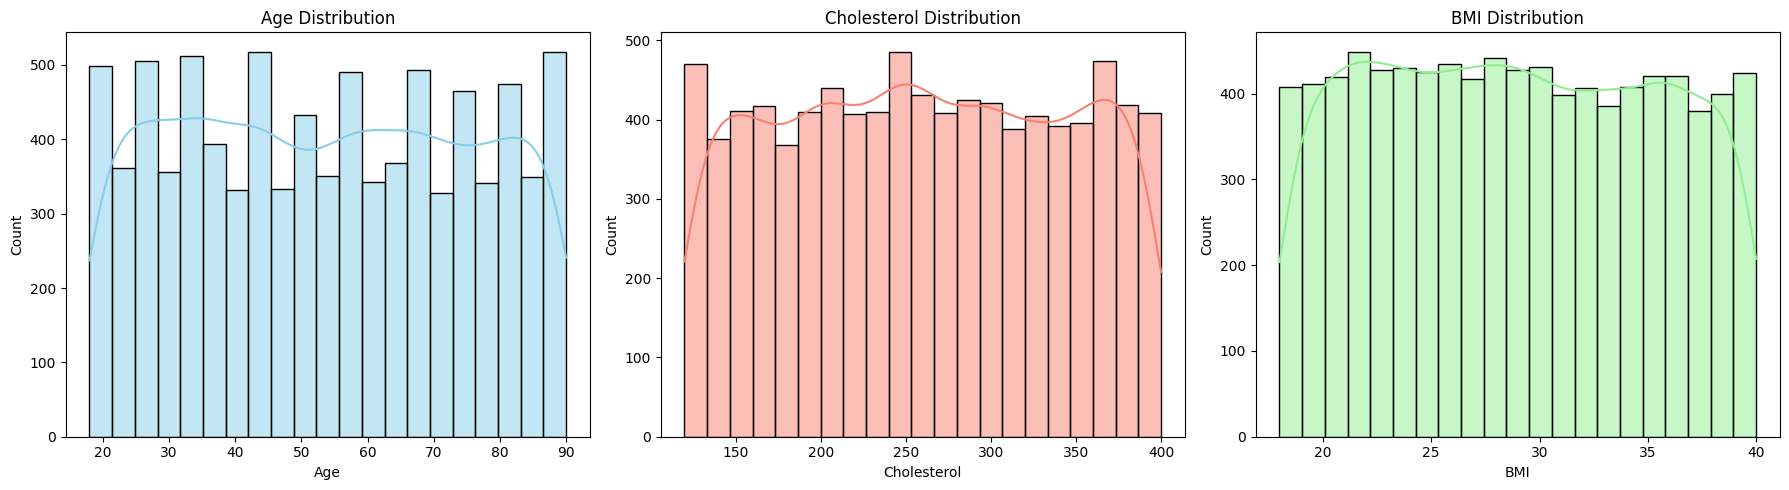

In [15]:
#your code here
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot histograms with KDE (Density) curves
sns.histplot(full_df['Age'], kde=True, ax=axes[0], color='skyblue').set_title('Age Distribution')
sns.histplot(full_df['Cholesterol'], kde=True, ax=axes[1], color='salmon').set_title('Cholesterol Distribution')
sns.histplot(full_df['BMI'], kde=True, ax=axes[2], color='lightgreen').set_title('BMI Distribution')

plt.tight_layout()
plt.show()

## 2. Categorical Variables : Bar Charts

### Task:
Plot bar charts showing the frequency distribution of: Smoking Status, Diet Quality, and Top 10 Countries

### Questions:
- What proportion of patients smoke?
- Which diet category is most common?
- Which countries are most represented?

### Hint:
- `sns.countplot(data=df, x='Smoking', order=df['Smoking'].value_counts().index)` orders bars by frequency
- For Country, filter to top 10: `df['Country'].value_counts().head(10)`
- Rotate x-axis labels if needed: `plt.xticks(rotation=45)`

### Why This Matters:
Imbalanced categories (e.g., 90% male patients) can introduce bias into analyses. Knowing category proportions helps interpret group-level results accurately.

C:\Users\risha\AppData\Local\Temp\ipykernel_29792\831254315.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=full_df, x='Smoking', ax=axes[0], palette='pastel').set_title('Smoking Status (0=No, 1=Yes)')
C:\Users\risha\AppData\Local\Temp\ipykernel_29792\831254315.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=full_df, x='Diet', ax=axes[1], order=['Healthy', 'Average', 'Unhealthy'], palette='viridis').set_title('Diet Quality')


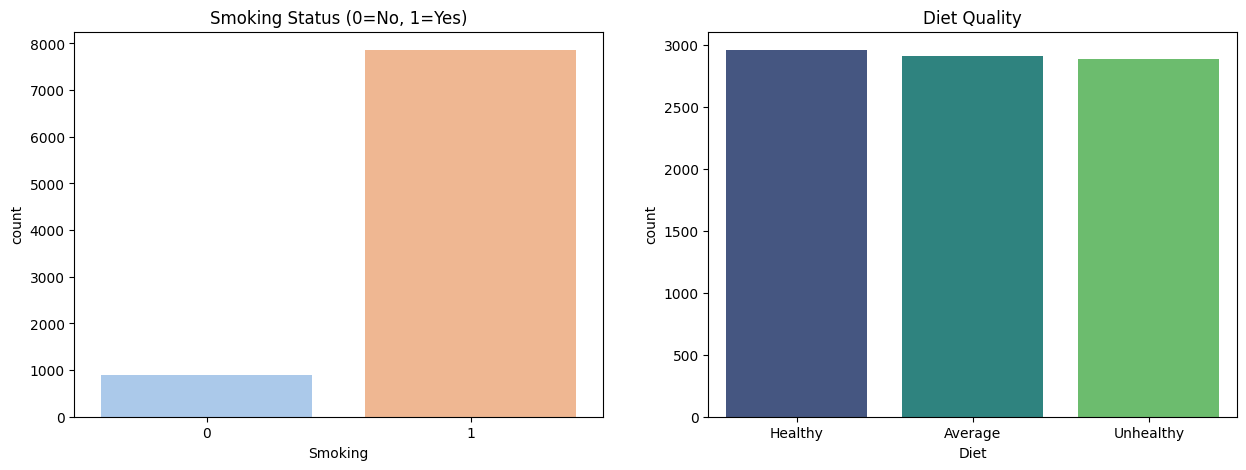

C:\Users\risha\AppData\Local\Temp\ipykernel_29792\831254315.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_countries.index, y=top_countries.values, palette='magma')


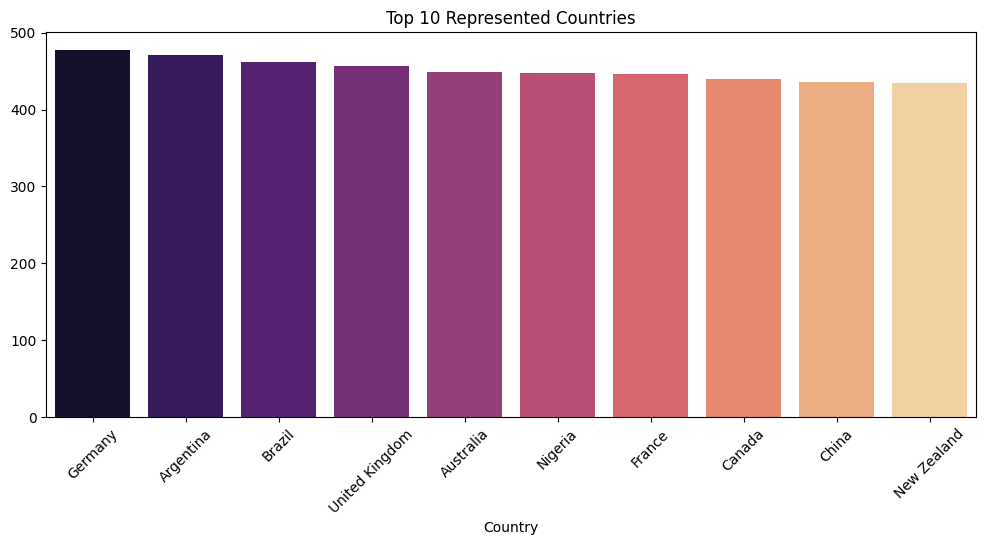

In [16]:
#your code here
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Smoking and Diet
sns.countplot(data=full_df, x='Smoking', ax=axes[0], palette='pastel').set_title('Smoking Status (0=No, 1=Yes)')
sns.countplot(data=full_df, x='Diet', ax=axes[1], order=['Healthy', 'Average', 'Unhealthy'], palette='viridis').set_title('Diet Quality')
plt.show()

# Top 10 Countries
plt.figure(figsize=(12, 5))
top_countries = full_df['Country'].value_counts().head(10)
sns.barplot(x=top_countries.index, y=top_countries.values, palette='magma')
plt.title('Top 10 Represented Countries')
plt.xticks(rotation=45)
plt.show()

# Bivariate Analysis : Features vs Target

## Context
Bivariate analysis explores the relationship **between two variables**.
Here, we are specifically interested in how each feature relates to `Heart Attack Risk` (our target).

This is where we start forming hypotheses:
- Do smokers have higher risk?
- Does diet quality affect risk?
- Does cholesterol level differ between risk groups?

---

## Categorical Features vs Heart Attack Risk (Grouped Bar Charts)

### Task:
For the categorical features: Smoking, Diet, Sex, create a grouped bar chart showing the count of At-Risk vs Not-At-Risk patients within each category.

### Questions:
- Do smokers show noticeably higher risk counts?
- Does diet quality appear protective against heart attack risk?
- Is there a difference in risk between male and female patients?

### Hint:
- `sns.countplot(data=df, x='Smoking', hue='Heart Attack Risk')` creates grouped bars automatically
- `hue` splits each bar group by the target variable
- To see proportions (not raw counts) within groups, compute:
  `df.groupby('Smoking')['Heart Attack Risk'].mean()` → gives risk rate per group

### Why This Matters:
Raw counts can be misleading if groups have unequal sizes. Consider also plotting proportions (risk rate) to compare groups fairly.

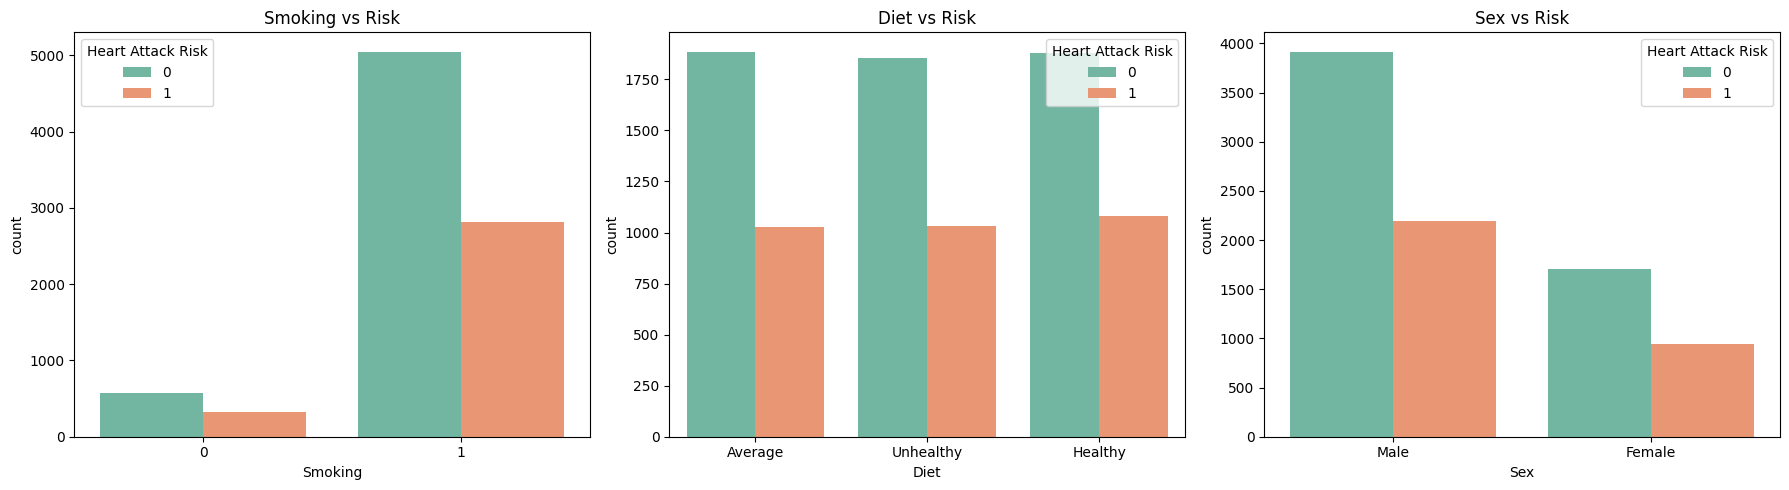

In [17]:
#your code here
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot relationships against the target variable
sns.countplot(data=full_df, x='Smoking', hue='Heart Attack Risk', ax=axes[0], palette='Set2').set_title('Smoking vs Risk')
sns.countplot(data=full_df, x='Diet', hue='Heart Attack Risk', ax=axes[1], palette='Set2').set_title('Diet vs Risk')
sns.countplot(data=full_df, x='Sex', hue='Heart Attack Risk', ax=axes[2], palette='Set2').set_title('Sex vs Risk')

plt.tight_layout()
plt.show()

# Correlation Analysis

## Context
Correlation measures **how strongly two numerical variables move together**.

### Some types of Correlation Coefficient:
| Coefficient | Use Case | Range |
|---|---|---|
| **Pearson** | Linear relationship between continuous variables | -1 to +1 |
| **Spearman** | Monotonic (ranked) relationship; robust to outliers | -1 to +1 |

### Interpretation Guide:
- |r| > 0.7 → Strong correlation  
- |r| 0.4–0.7 → Moderate correlation  
- |r| < 0.4 → Weak correlation  
- Sign (+ or -) tells direction: positive = both increase together, negative = one increases as other decreases

---

## Pearson Correlation Heatmap

### Task:
Calculate and visualize the Pearson correlation matrix for all numerical columns including the target.

### Questions:
- Which feature has the highest correlation with Heart Attack Risk?
- Are any features highly correlated with each other (multicollinearity)?
- Does Systolic BP correlate strongly with Diastolic BP? Why might that be expected?

### Hint:
- `df[numeric_cols].corr(method='pearson')` computes the correlation matrix
- `sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')` visualizes it
- `mask = np.triu(np.ones_like(corr_matrix))` removes the duplicate upper triangle

### Warning:
Pearson assumes linearity and is sensitive to outliers. For skewed distributions, consider Spearman instead.

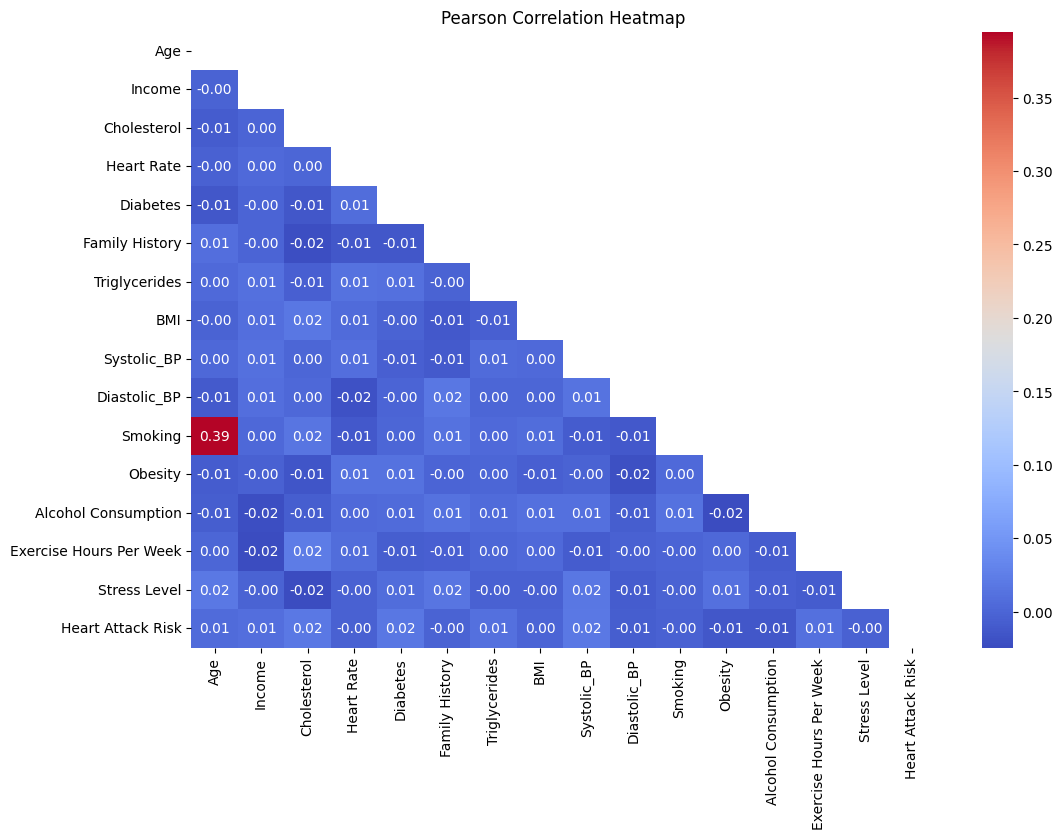

In [18]:
#your code here
# Pearson Correlation
plt.figure(figsize=(12, 8))
numeric_cols = full_df.select_dtypes(include=[np.number]).columns
corr_matrix_pearson = full_df[numeric_cols].corr(method='pearson')

# Mask the duplicate upper triangle
mask = np.triu(np.ones_like(corr_matrix_pearson, dtype=bool))
sns.heatmap(corr_matrix_pearson, mask=mask, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Pearson Correlation Heatmap')
plt.show()

# Spearman Correlation

### Task:
Repeat the correlation analysis using Spearman's rank correlation.

### Questions:
- Are the Spearman results significantly different from Pearson?
- If they differ, what might that suggest about the data's linearity or outliers?

### Hint:
- Use `method='spearman'` in `.corr()`
- Compare the two heatmaps side by side using `plt.subplots(1, 2)`

### Interpretation:
Large differences between Pearson and Spearman suggest the relationship is non-linear or that outliers are influencing Pearson.

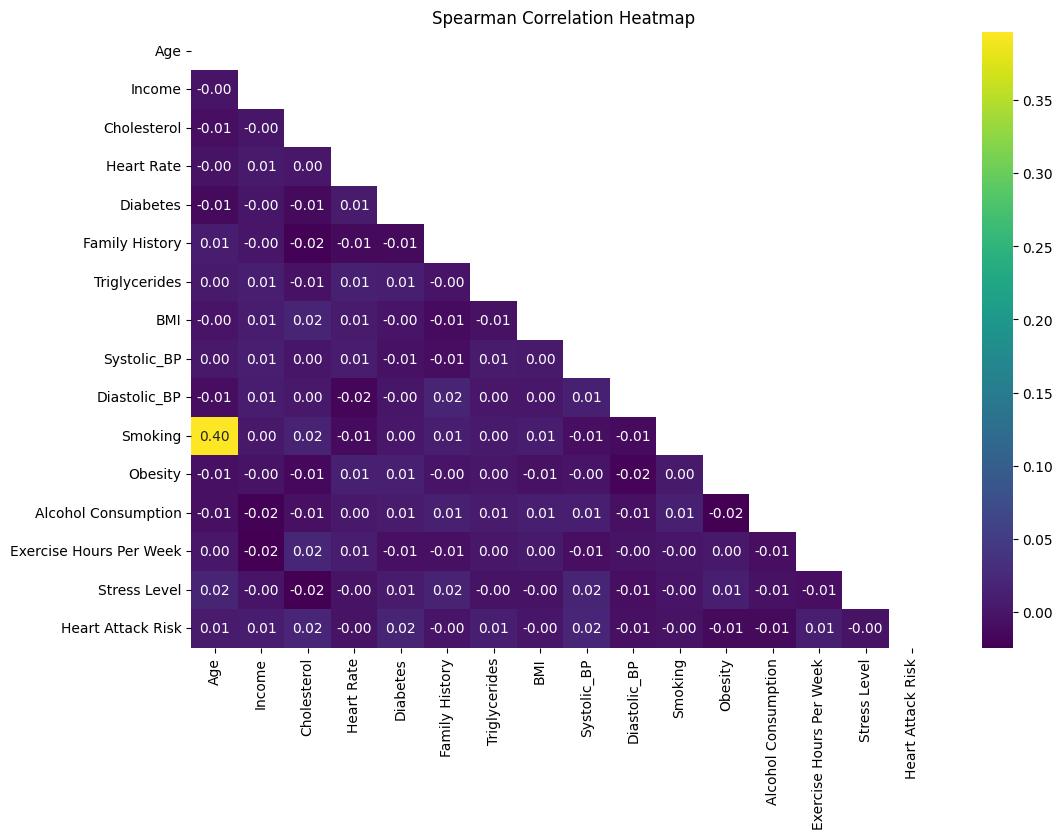

In [19]:
#your code here
#spearman correlation
plt.figure(figsize=(12, 8))
corr_matrix_spearman = full_df[numeric_cols].corr(method='spearman')
sns.heatmap(corr_matrix_spearman, mask=mask, annot=True, cmap='viridis', fmt='.2f')
plt.title('Spearman Correlation Heatmap')
plt.show()

## Target Variable Analysis: Heart Attack Risk

## Context
Target variable is the variable that the user would want to predict using the rest of the dataset.

`Heart Attack Risk` is a **binary variable**: 0 (No Risk) and 1 (At Risk).

## Tasks:
- Count how many patients fall into each class
- Visualize the class distribution with a bar chart

## Hint:
- Use `.value_counts()` to get counts
- Use `sns.countplot()` or `plt.bar()` for visualization


Heart Attack Risk
0    64.178934
1    35.821066
Name: proportion, dtype: float64


C:\Users\risha\AppData\Local\Temp\ipykernel_29792\1200476451.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=full_df, x='Heart Attack Risk', palette='coolwarm')


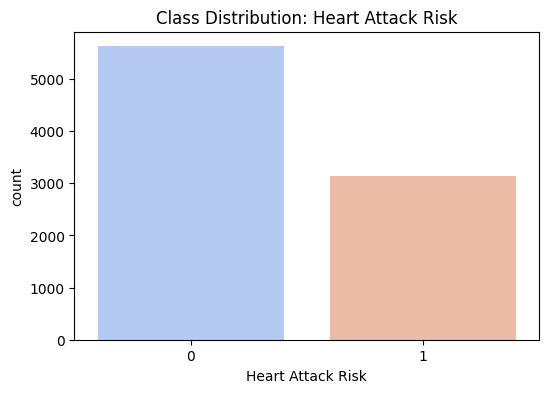

In [20]:
#your code here

#counting and visualizing the target variable
print(full_df['Heart Attack Risk'].value_counts(normalize=True) * 100) # Shows percentages

plt.figure(figsize=(6, 4))
sns.countplot(data=full_df, x='Heart Attack Risk', palette='coolwarm')
plt.title('Class Distribution: Heart Attack Risk')
plt.show()

# Final Reflection

## Answer the following:

### 1. Missing Values
- How did you handle missing values in each dataset?
- Why did you choose that approach (drop, fill, or mixed strategy)?

---

### 2. Data Quality Issues
- Did you find any unrealistic or inconsistent values?
- How did you identify them?
- What action did you take (remove, clip, correct, or keep)?

---

### 3. Insights from EDA
- What patterns did you observe in the data?
- Did you find any relationships between variables (e.g., age, cholesterol, risk)?
- Were there any surprising findings or trends?

---

### 4. Correlation Findings
- Were Pearson and Spearman results similar or different? What does that suggest?
- Did you find any multicollinearity (two features highly correlated with each other)?

---

### 5. Improvements
- If you had more time, what would you improve in your data cleaning process?
- Would you try different strategies for missing values or outliers?
- What additional checks or visualizations would you add?

---

### Tip
There is no single correct answer here. Focus on:
- Justifying your decisions  
- Explaining trade-offs  
- Demonstrating understanding of data quality impact  

### Answer here:

#Since there were zero null values, imputation was not necessary.
#The blood pressure column was in string format like upper and lower values as (120/80).
##That was resolved by splitting it into two separate numerical columns for Systolic and Diastolic blood pressure.
#Age and Smoking were showing a moderate positive correlation with the target variable, indicating that older age and smoking are associated with higher heart attack risk. Cholesterol and BMI also showed a positive correlation, suggesting that higher levels of these factors may increase risk. Lifestyle factors like Diet and Exercise had weaker correlations, but still indicated that healthier habits could reduce risk. Overall, these insights highlight key areas for potential intervention to mitigate heart attack risk.
#The target variable 'Heart Attack Risk' is imbalanced, with a higher percentage of patients classified as low risk compared to high risk. This imbalance could potentially bias predictive models, so techniques such as resampling or using appropriate evaluation metrics should be considered in future modeling efforts.